In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [ ]:
df.dtypes

Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

In [ ]:
df.shape

(3900, 19)

In [ ]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

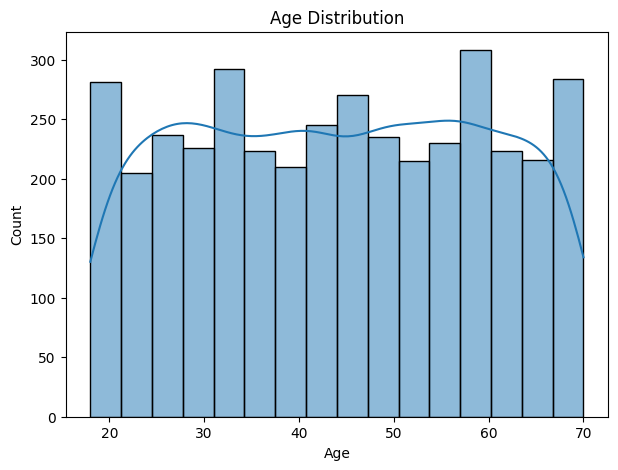

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

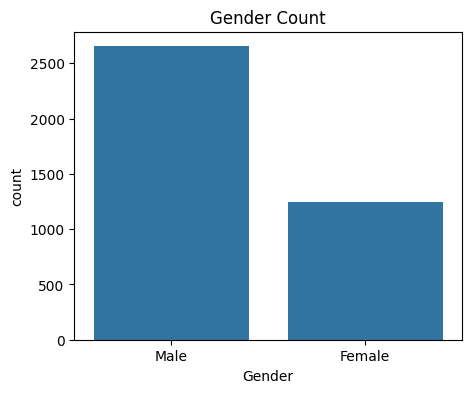

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['Gender'])
plt.title("Gender Count")
plt.show()

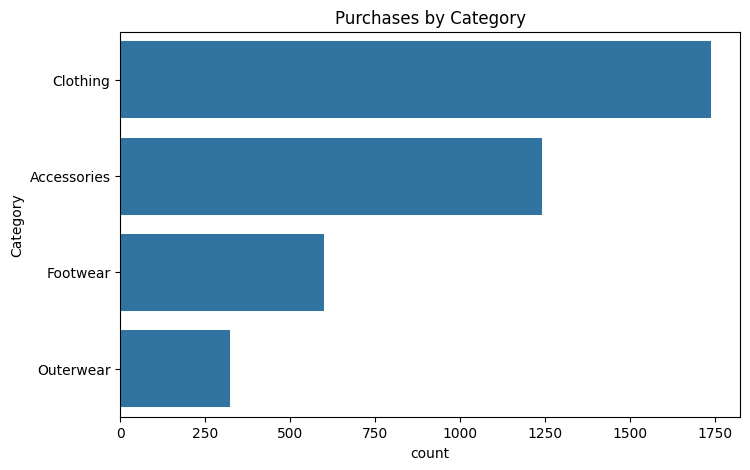

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['Category'],
              order=df['Category'].value_counts().index)

plt.title("Purchases by Category")
plt.show()

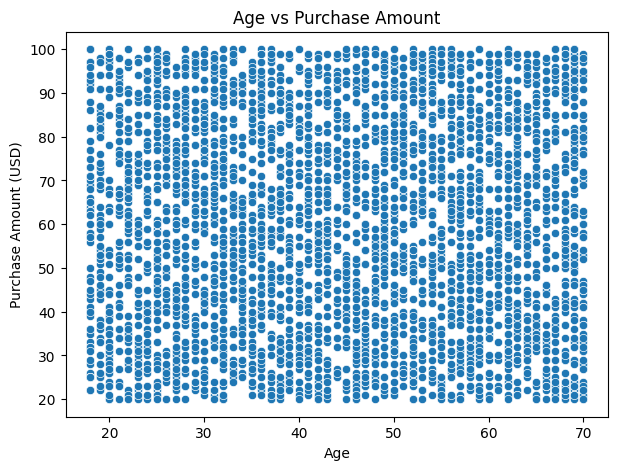

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Age'],
                y=df['Purchase Amount (USD)'])

plt.title("Age vs Purchase Amount")
plt.show()

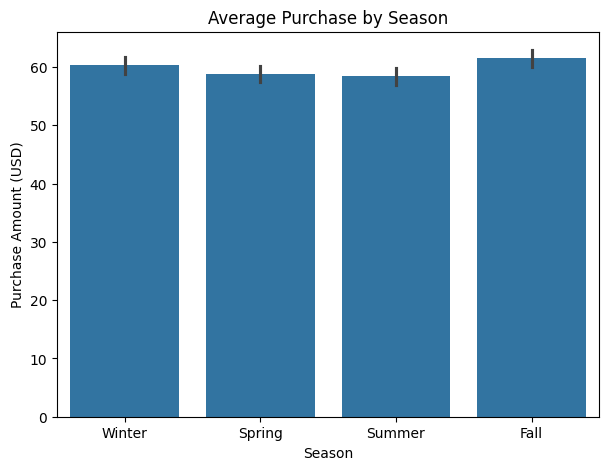

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x='Season',
            y='Purchase Amount (USD)',
            data=df)

plt.title("Average Purchase by Season")
plt.show()

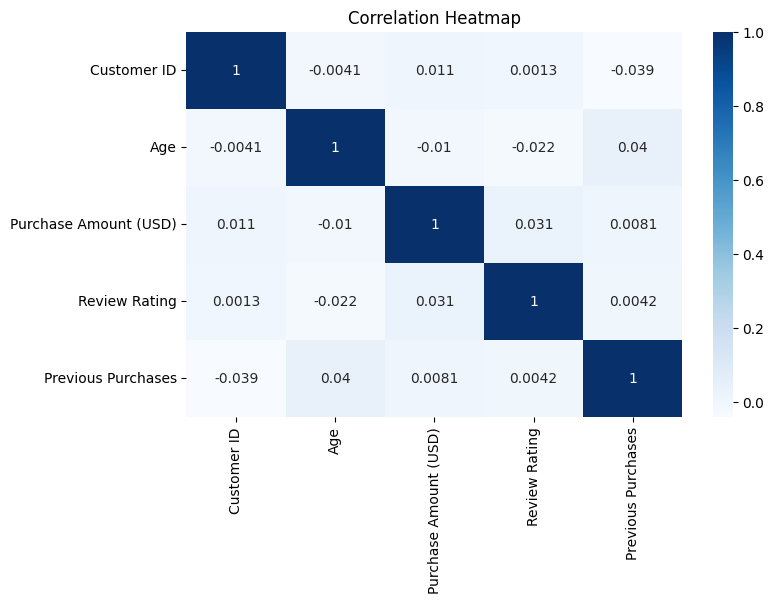

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.drop('Customer ID', axis=1, inplace=True)

In [ ]:
onehot_cols = [
    'Gender',
    'Category',
    'Season',
    'Payment Method',
    'Size',
    'Shipping Type',
    'Frequency of Purchases',
    'Preferred Payment Method',
    'Promo Code Used',
    'Discount Applied',
]

df= pd.get_dummies(df,
                            columns=onehot_cols,
                            drop_first=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
label_cols = ['Item Purchased', 'Location', 'Color']
for col in label_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.drop('Subscription Status',axis=1)
y=df['Subscription Status']
y = le.fit_transform(y)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: >

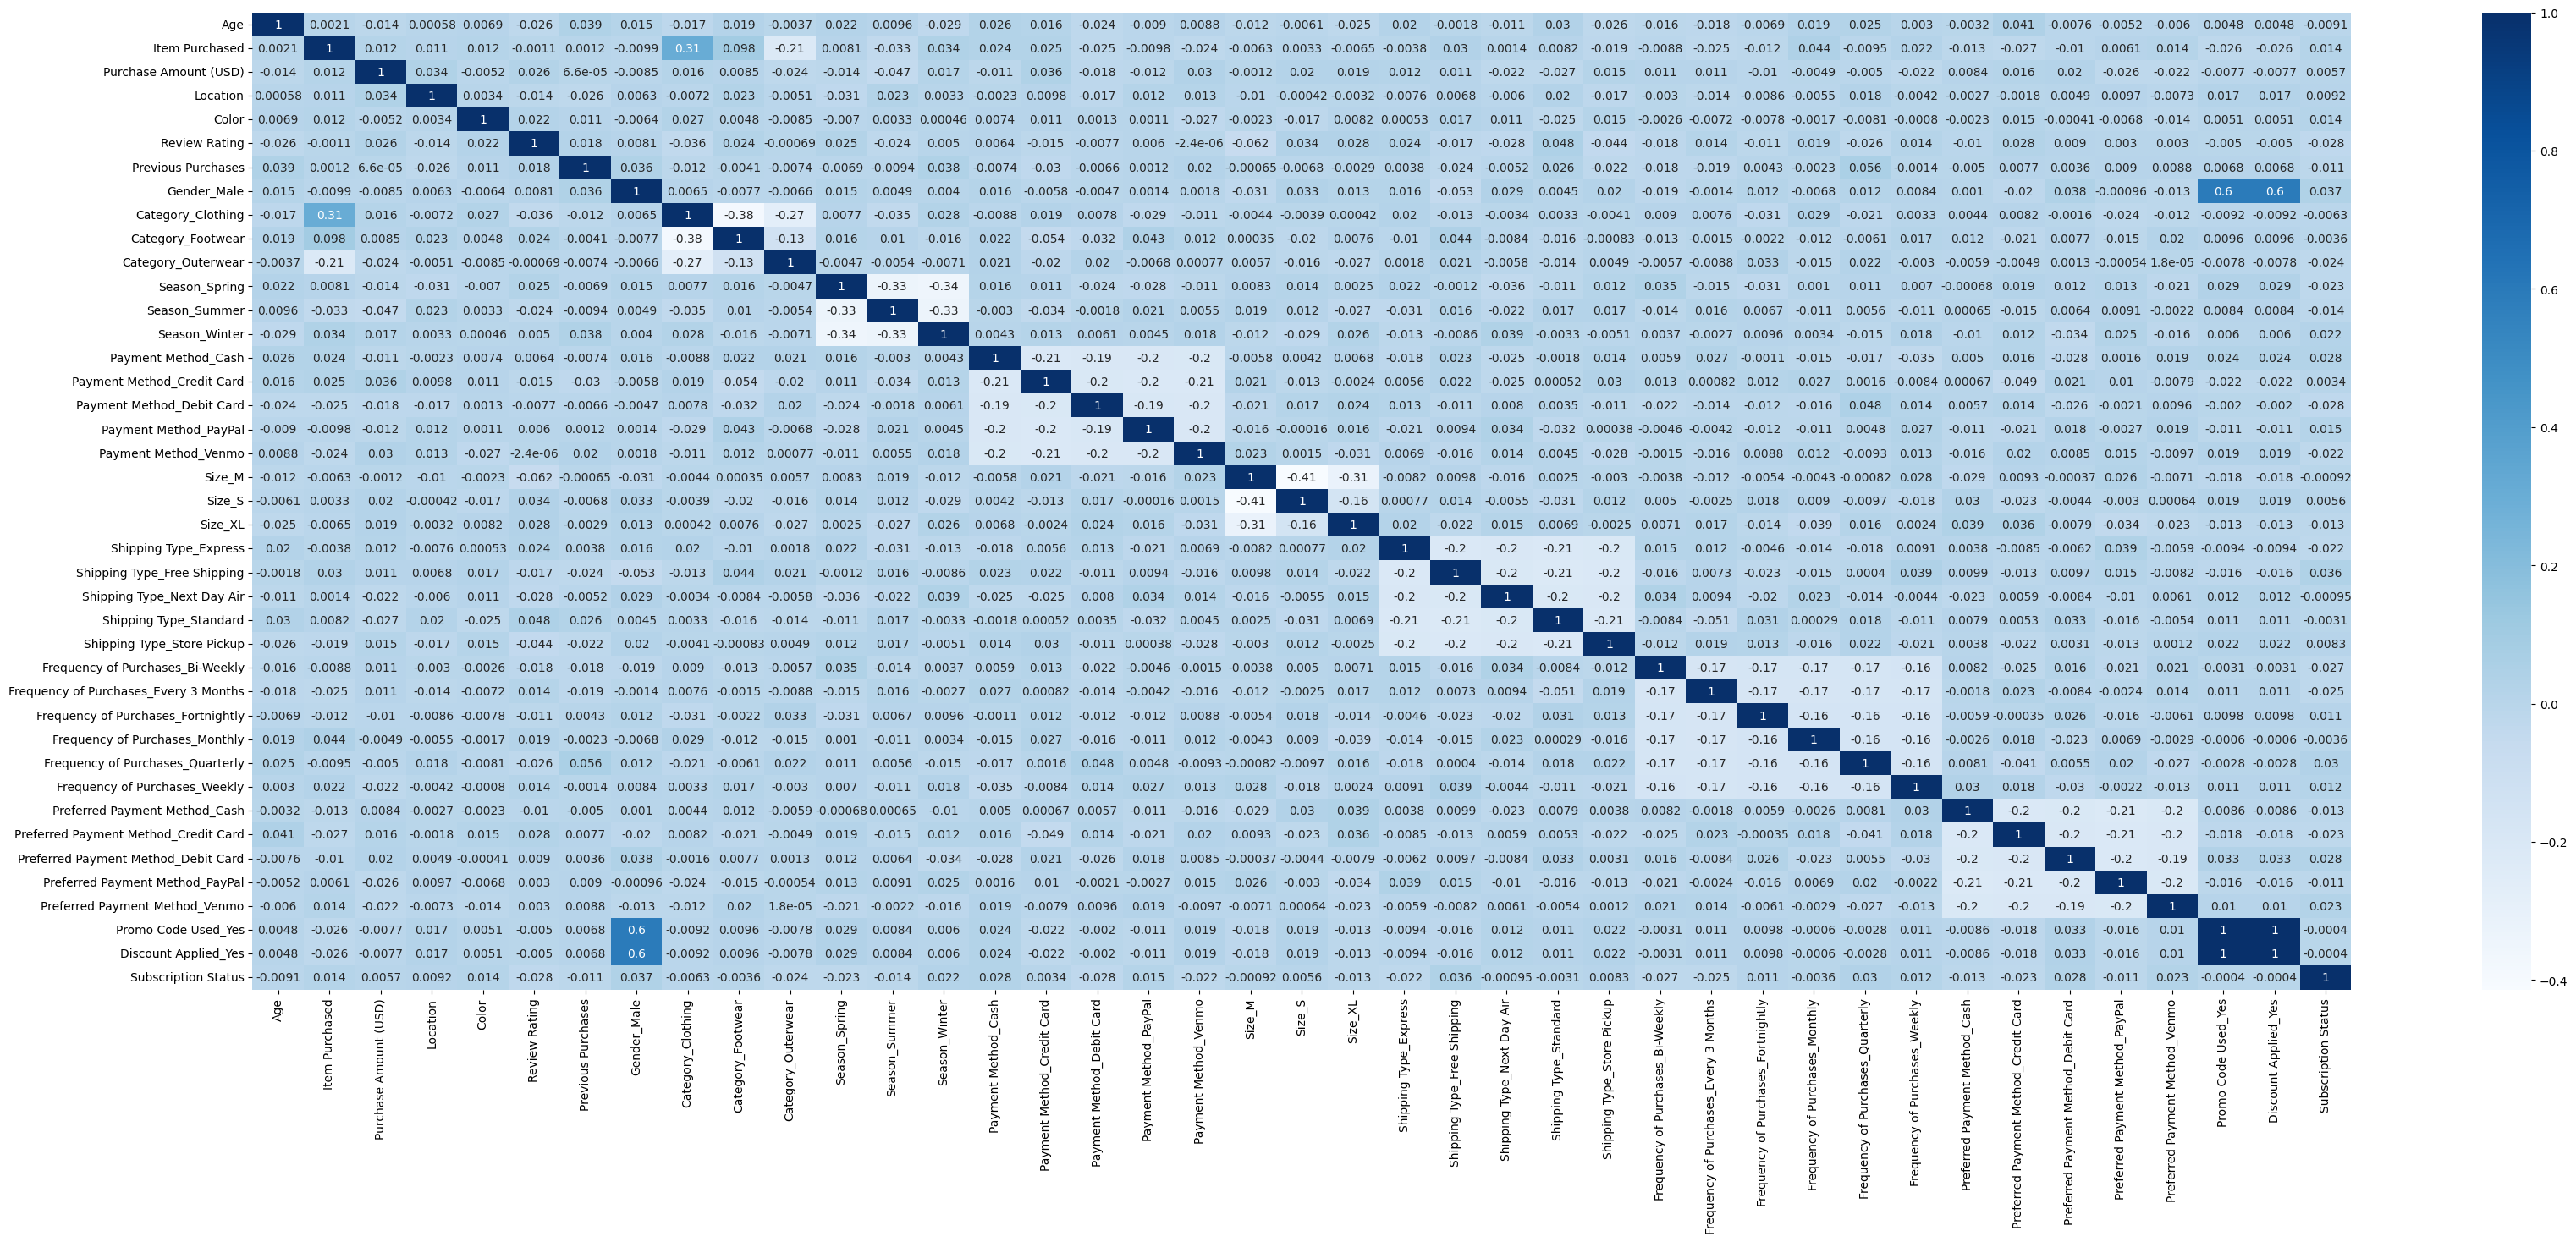

In [ ]:
plt.figure(figsize=(40,15))
sns.heatmap(pd.concat([x_train,pd.Series(y_train,name='Subscription Status')],axis=1).corr(),annot=True,cmap='Blues')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


In [ ]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(),

    "XGBoost":
    XGBClassifier(
        eval_metric='logloss'
    )
}

In [ ]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
3,Gradient Boosting,0.825641
0,Logistic Regression,0.817949
2,Random Forest,0.816667
4,XGBoost,0.811538
1,Decision Tree,0.783333


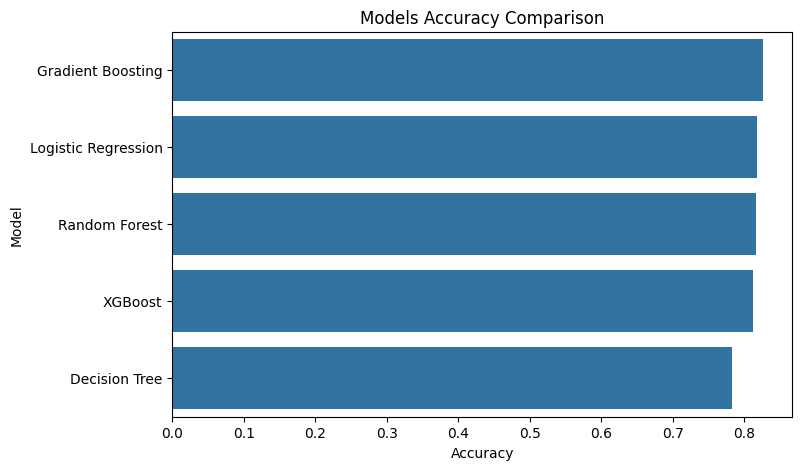

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df
)

plt.title("Models Accuracy Comparison")

plt.show()